In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE, Isomap, MDS
import umap
import matplotlib.patches as mpatches
from scipy.stats import entropy
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_SYMBOLIC = PROJECT_ROOT / "data" / "symbolic"
DATA_SYMBOLIC.mkdir(parents=True, exist_ok=True)

DATA_CLUSTER = PROJECT_ROOT / "data" / "cluster"
DATA_CLUSTER.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", DATA_CLUSTER)

Processed data folder: c:\Users\ccana\Documents\Doutorado\VISEMTracking\data\cluster


Matriz de Acoplamento <Cluster Simbólico, Cluster Físico>:
phys_cluster    0    1   2    3   4
cluster                            
0              25   89   0   20   0
1               1   69   0  125  36
2               0   28   0   16  52
3              11  109   0   47   4
4             103   19  26   27   0


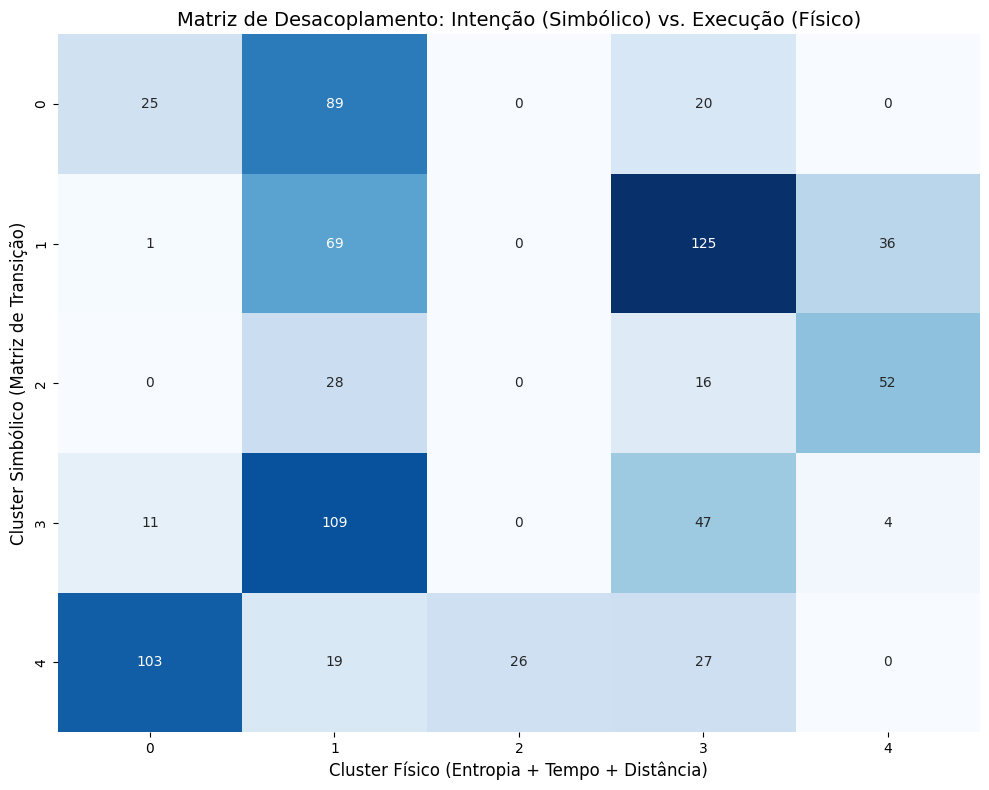

In [8]:

# 1. Carregar os dados
# Certifique-se de que o arquivo symbolic.csv está na mesma pasta
df = pd.read_csv('symbolic.csv')

# ---------------------------------------------------------
# Passo 2: Engenharia de Atributos (Feature Engineering)
# Precisamos calcular a distância total (Path Length) pois ela é 
# um proxy melhor para "Gasto Energético" do que a velocidade média
# ---------------------------------------------------------
def get_path_length(traj_str):
    try:
        # Converte a string da trajetória em array numpy
        points = np.array(ast.literal_eval(traj_str))
        if len(points) < 2: return 0
        # Calcula distâncias euclidianas passo a passo
        diffs = np.diff(points, axis=0)
        return np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    except:
        return 0

df['path_length'] = df['trajectory_xy'].apply(get_path_length)

# ---------------------------------------------------------
# Passo 3: Clusterização Física (O "Hardware" do Espermatozoide)
# Selecionamos apenas as variáveis de eficiência física/energética
# ---------------------------------------------------------
phys_features = ['shannon_entropy', 'avg_dwell_time', 'path_length']

# Removemos linhas com falha no cálculo (se houver)
X_phys = df[phys_features].dropna()

# NORMALIZAÇÃO (Crítico!):
# Tempo varia de 0 a 100, Entropia de 0 a 3. Sem isso, o Tempo domina o cluster.
scaler = StandardScaler()
X_phys_scaled = scaler.fit_transform(X_phys)

# Aplicamos K-Means
# n_clusters=5 é sugerido para manter paridade com os clusters originais
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['phys_cluster'] = kmeans.fit_predict(X_phys_scaled)

# ---------------------------------------------------------
# Passo 4: Cruzamento e Visualização
# Geramos a matriz que mostra quantos espermatozoides de cada 
# "Estratégia" (Cluster Original) caem em cada "Desempenho" (Cluster Físico)
# ---------------------------------------------------------
cross_matrix = pd.crosstab(df['cluster'], df['phys_cluster'])

# Exibir no console
print("Matriz de Acoplamento <Cluster Simbólico, Cluster Físico>:")
print(cross_matrix)

# Plotar Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Matriz de Desacoplamento: Intenção (Simbólico) vs. Execução (Físico)', fontsize=14)
plt.ylabel('Cluster Simbólico (Matriz de Transição)', fontsize=12)
plt.xlabel('Cluster Físico (Entropia + Tempo + Distância)', fontsize=12)

plt.tight_layout()
plt.show() # Ou plt.savefig('matriz_acoplamento.png')

In [9]:
df['cluster'].value_counts()

cluster
1    231
4    175
3    171
0    134
2     96
Name: count, dtype: int64

In [10]:
df.to_csv("symbolic2.csv", index=False)